In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('BlackFriday.csv')

In [3]:
df.shape

(537577, 12)

In [4]:
df.isna().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

In [5]:
del df['Product_Category_2']
del df['Product_Category_3']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     537577 non-null  int64 
 1   Product_ID                  537577 non-null  object
 2   Gender                      537577 non-null  object
 3   Age                         537577 non-null  object
 4   Occupation                  537577 non-null  int64 
 5   City_Category               537577 non-null  object
 6   Stay_In_Current_City_Years  537577 non-null  object
 7   Marital_Status              537577 non-null  int64 
 8   Product_Category_1          537577 non-null  int64 
 9   Purchase                    537577 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 41.0+ MB


### Analyzing Column

In [7]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [8]:
df['User_ID'].nunique()  ## there are 5891 users 

5891

In [9]:
df['Product_ID'].nunique()  ## there are 3623 unique products 

3623

In [10]:
df['Age'].unique()  ## there are total 7 age groups involved in this

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [11]:
df['Occupation'].nunique() ## therefore customers are from 21 unique occupations

21

In [12]:
df['City_Category'].unique()  ## 3 categories of city

array(['A', 'C', 'B'], dtype=object)

In [13]:
df['Stay_In_Current_City_Years'].unique() ## 5 unique values 

array(['2', '4+', '3', '1', '0'], dtype=object)

In [14]:
df_purchases = df.groupby(by='User_ID')['Purchase'].sum()  

In [15]:
df_purchases.values.sum()/len(df_purchases)  ## average purchase by an user 

851751.5494822611

## Analysing gender

In [16]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
df[df['Gender']=='M']['User_ID'].nunique() ## no. of male customers

4225

In [ ]:
df[df['Gender']=='F']['User_ID'].nunique() ## no. of female customer 

1666

In [23]:
Gender_data = pd.DataFrame({'Count' :[df[df['Gender']=='M']['User_ID'].nunique() , df[df['Gender']=='F']['User_ID'].nunique()]} , index=['Male' , 'Female'])

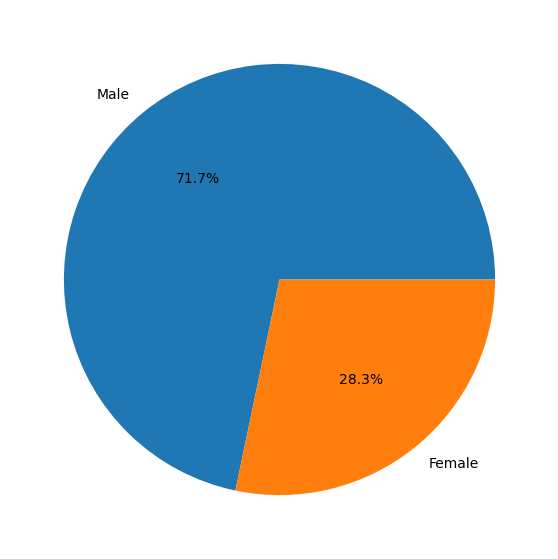

In [31]:
plt.figure(figsize=(7,7))
plt.pie(Gender_data['Count'] ,autopct='%.1f%%' , labels=Gender_data.index)
plt.show()

### Approach 2

In [50]:
df.groupby('Gender')['User_ID'].nunique()

Gender
F    1666
M    4225
Name: User_ID, dtype: int64

<Axes: ylabel='User_ID'>

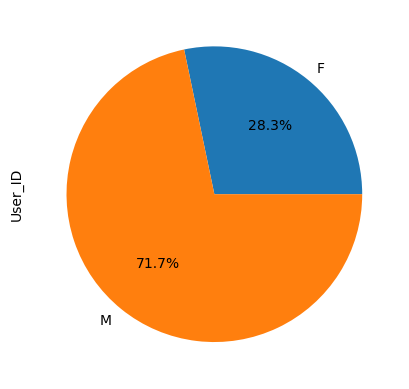

In [51]:
df.groupby('Gender')['User_ID'].nunique().plot(kind='pie' , autopct = '%.1f%%')

### amount they have have spent 

In [ ]:
df.groupby('Gender')['Purchase'].sum()

Gender
F    1164624021
M    3853044357
Name: Purchase, dtype: int64

<Axes: ylabel='Purchase'>

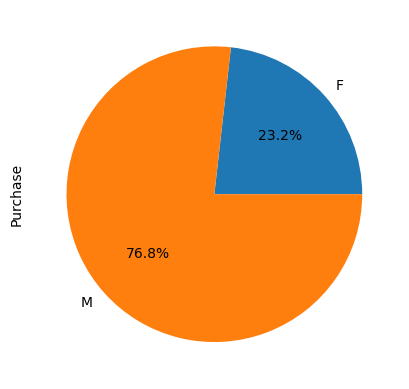

In [59]:
df.groupby('Gender')['Purchase'].sum().plot(kind='pie' , autopct='%.1f%%')

In [ ]:
df.groupby('Gender')['Purchase'].mean()

Gender
F    8809.761349
M    9504.771713
Name: Purchase, dtype: float64

<Axes: ylabel='Purchase'>

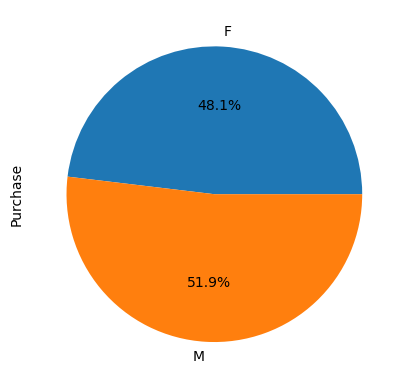

In [61]:
df.groupby('Gender')['Purchase'].mean().plot(kind='pie' , autopct='%.1f%%')